# Tutorial Debug — Per-Tier Training & Analysis

Train a DQN agent on **individual tutorial tiers** (up to 75 epochs each,
early-stop on mastery), then run each scenario with a greedy policy for
detailed move-by-move debugging.

**Flow per tier:**
1. Train agent on that tier's scenarios (75 epochs max, early stop at 90% mastery)
2. Switch to greedy policy (epsilon=0, noise off)
3. Run each scenario once with structured per-move logging
4. Restore exploration for next tier

Works with any agent variant (Baseline, NoisyNet, Dueling, IQN, Kitchen Sink, etc.).
Tiers are trained cumulatively — the agent carries over knowledge from prior tiers.

In [1]:
import sys, os, time, random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, deque

# Ensure project root is on path
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))
elif os.path.isdir(os.path.join(_cwd, "simulation")):
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

Project root: /home/franko/CT-DRL-MA
PyTorch: 2.10.0+cu128
CUDA: True


In [2]:
# ================================================================
# Configuration — change these to select variant and training params
# ================================================================

VARIANT = "noisynet"            # "baseline", "noisynet", "dueling", "iqn", "qrdqn",
                                # "munchausen", "spectralnorm", "kitchen_sink"
BACKBONE = "baseline"           # "baseline", "wider", "deeper", "residual",
                                # "narrow_deep", "kitchen_sink"
MAX_EPOCHS_PER_TIER = 75        # Max training epochs per tier
MASTERY_THRESHOLD = 0.9         # 90% pass rate to consider mastered
WINDOW_SIZE = 20                # Rolling window for pass rate
MIN_EPOCHS = 10                 # Min epochs before mastery check
LOG_EVERY = 10                  # Print progress every N epochs

print(f"Variant:    {VARIANT}")
print(f"Backbone:   {BACKBONE}")
print(f"Max epochs: {MAX_EPOCHS_PER_TIER} per tier")
print(f"Mastery:    {MASTERY_THRESHOLD:.0%} over window of {WINDOW_SIZE}")

Variant:    noisynet
Backbone:   baseline
Max epochs: 75 per tier
Mastery:    90% over window of 20


In [3]:
from simulation.rl.agent_registry import create_agent
from simulation.training.curriculum_trainer import (
    create_env_factory, build_agent_config,
)
from simulation.training.scenarios import (
    ALL_SCENARIOS, SCENARIO_BY_ID, TIER_DEFS,
    ONE_SHOT_SCENARIOS, REPEATABLE_SCENARIOS,
    TutorialResult, MoveRecord, StepEvent,
    visualize_scenario,
)
from simulation.training.tutorial_runner import (
    TutorialRunner, TUTORIAL_TIERS,
    TUTORIAL_REWARD_SUCCESS, TUTORIAL_REWARD_TIMEOUT,
)

# ---- Environment & Agent ----
env_factory = create_env_factory(rows=5, bays=58, tiers=5, tracks=7, split_factor=20)
base_cfg = build_agent_config(rows=5, bays=58, tiers=5, split_factor=20, tracks=7)

agent = create_agent(VARIANT, base_cfg, backbone_variant=BACKBONE)

n_params = sum(p.numel() for p in agent.q_net.parameters())
print(f"{VARIANT} agent created (from scratch)")
print(f"  Parameters: {n_params:,}")
print(f"  Backbone:   {type(agent.q_net.backbone).__name__}")
print(f"  Device:     {base_cfg.device}")
print(f"  Scenarios:  {len(ALL_SCENARIOS)} total "
      f"({len(ONE_SHOT_SCENARIOS)} one-shot, {len(REPEATABLE_SCENARIOS)} repeatable)")
print(f"  Tiers:      {len(TUTORIAL_TIERS)}")

runner = TutorialRunner(
    env_factory=env_factory,
    agent_or_config=agent,
    verbose=False,
)

# Global stores for cross-tier summary
ALL_RESULTS: dict[int, TutorialResult] = {}
TIER_TRAINING: dict[int, dict] = {}

print("Runner ready")

noisynet agent created (from scratch)
  Parameters: 143,973
  Backbone:   FactoredCNNBackbone
  Device:     cuda
  Scenarios:  31 total (11 one-shot, 20 repeatable)
  Tiers:      13
Runner ready


/home/franko/.cache/pypoetry/virtualenvs/ct-drl-ma-7RJlkqYG-py3.12/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KernelDensity from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
# ================================================================
# Training, debug, and display functions
# ================================================================

try:
    from simulation.rl.variants.networks.noisy_linear import NoisyLinear
    _HAS_NOISY = True
except ImportError:
    _HAS_NOISY = False


def _has_noisy_layers() -> bool:
    """Check whether the current agent uses NoisyLinear layers."""
    if not _HAS_NOISY:
        return False
    return any(isinstance(m, NoisyLinear) for m in agent.q_net.modules())


def train_single_tier(
    tier_idx: int,
    max_epochs: int = MAX_EPOCHS_PER_TIER,
    mastery_threshold: float = MASTERY_THRESHOLD,
    window_size: int = WINDOW_SIZE,
    min_epochs: int = MIN_EPOCHS,
    log_every: int = LOG_EVERY,
) -> dict:
    """Train agent on a single tier. Stops early if mastered."""
    tier = TUTORIAL_TIERS[tier_idx]
    history = {s.id: deque(maxlen=window_size) for s in tier.scenarios}

    t0 = time.time()
    mastered = False
    epoch = 0

    sep = "=" * 70
    print()
    print(sep)
    print(f"  Training Tier {tier_idx}: {tier.name}")
    print(f"  Scenarios: {', '.join(f'S{s.id}' for s in tier.scenarios)}")
    print(f"  Max epochs: {max_epochs}  |  Mastery: {mastery_threshold:.0%}")
    print(sep)

    for epoch in range(max_epochs):
        agent.set_tutorial_epsilon(epoch)
        agent.set_tutorial_noise(epoch)          # anneal NoisyNet (no-op for others)

        # Run all scenarios in this tier
        steps = 0
        for sc in tier.scenarios:
            result = runner.run_scenario(sc)
            history[sc.id].append(1 if result.passed else 0)
            steps += result.steps

        # Optimize from replay buffer
        n_optim = min(10, max(1, steps // 4))
        for _ in range(n_optim):
            agent.optimize()

        # Compute pass rates
        pass_rates = {}
        for sid, hist in history.items():
            pass_rates[sid] = sum(hist) / len(hist) if len(hist) > 0 else 0.0
        avg_rate = np.mean(list(pass_rates.values()))

        # Log progress
        if (epoch + 1) % log_every == 0 or epoch == 0:
            rates_str = "  ".join(f"S{sid}={r:.0%}" for sid, r in sorted(pass_rates.items()))
            print(f"  Epoch {epoch+1:>3d}/{max_epochs}  avg={avg_rate:.0%}  {rates_str}")

        # Mastery check
        if epoch + 1 >= min_epochs and epoch + 1 >= window_size:
            if all(r >= mastery_threshold for r in pass_rates.values()):
                mastered = True
                rates_str = "  ".join(f"S{sid}={r:.0%}" for sid, r in sorted(pass_rates.items()))
                print(f"  Epoch {epoch+1:>3d}/{max_epochs}  avg={avg_rate:.0%}  {rates_str}")
                print(f"  >>> MASTERED at epoch {epoch+1}")
                break

    wall = time.time() - t0
    status = "MASTERED" if mastered else "NOT MASTERED"
    print()
    print(f"  Result: {status} in {epoch+1} epochs ({wall:.1f}s)")
    print(sep)

    return {
        "tier": tier_idx,
        "tier_name": tier.name,
        "epochs": epoch + 1,
        "mastered": mastered,
        "pass_rates": pass_rates,
        "wall_time": wall,
    }


def debug_tier(tier_idx: int) -> list[TutorialResult]:
    """Run each scenario once with greedy policy and return detailed results."""
    # ---- Enter greedy mode ----
    saved_override = agent.epsilon_override
    agent.epsilon_override = 0.0

    # For NoisyNet variants: silence noise via set_noise_scale
    is_noisy = _has_noisy_layers()
    if is_noisy:
        agent.set_noise_scale(0.0)

    # ---- Run scenarios ----
    tier = TUTORIAL_TIERS[tier_idx]
    results = []
    for sc in tier.scenarios:
        result = runner.run_scenario(sc)
        results.append(result)
        ALL_RESULTS[sc.id] = result

    # ---- Restore exploration ----
    agent.epsilon_override = saved_override
    if is_noisy:
        agent.set_noise_scale(1.0)

    # ---- Display ----
    display_tier_summary(f"Tier {tier_idx}: {tier.name}", results)
    for r in results:
        display_scenario_result(r, show_moves=True)

    return results


def display_scenario_result(result: TutorialResult, show_moves: bool = True):
    """Print structured per-move log for one scenario result."""
    status = "PASS" if result.passed else "FAIL"
    repeatable = SCENARIO_BY_ID[result.scenario_id].repeatable
    tag = "repeatable" if repeatable else "one-shot"

    sep = "=" * 90
    print()
    print(sep)
    print(f"S{result.scenario_id}: {result.name}  [{status}]  ({tag})")
    print(f"  total_reward={result.total_reward:+.4f}  "
          f"steps={result.steps}  moves={result.agent_moves}")
    if result.move_type_counts:
        types_str = ", ".join(f"{k}={v}" for k, v in sorted(result.move_type_counts.items()))
        print(f"  move types: {types_str}")
    if result.reward_breakdown:
        bd_str = ", ".join(f"{k}={v:+.2f}" for k, v in sorted(result.reward_breakdown.items()))
        print(f"  reward breakdown: {bd_str}")
    print(sep)

    if not show_moves:
        return

    if not result.move_log and not result.step_events:
        print("  (no moves or events)")
        return

    # Build timeline: moves + events sorted by step
    timeline = []
    for m in result.move_log:
        timeline.append((m.step, 1, "move", m))
    for e in result.step_events:
        timeline.append((e.step, 0, "event", e))
    timeline.sort(key=lambda x: (x[0], x[1]))

    hdr = "  {:>3s}  {:>4s}  {:>6s}  {:<28s}  {:<14s}  {:>7s}  {:>7s}  {:>9s}  {}"
    print(hdr.format("#", "Step", "Kind", "Move Type", "ID", "Dist", "Time", "Reward", "Notes"))
    print("  {}  {}  {}  {}  {}  {}  {}  {}  {}".format(
        "-"*3, "-"*4, "-"*6, "-"*28, "-"*14, "-"*7, "-"*7, "-"*9, "-"*20))

    for step_val, _, kind, data in timeline:
        if kind == "move":
            m = data
            flags = []
            productive = {"TRAIN_TO_YARD", "TRUCK_TO_YARD", "YARD_TO_TRAIN",
                          "YARD_TO_TRUCK", "TRAIN_TO_TRUCK", "TRUCK_TO_TRAIN",
                          "YARD_TO_TERMINAL_TRUCK"}
            if m.move_type in productive and m.reward < 0:
                flags.append("NEG_PROD")
            if m.move_type == "YARD_TO_YARD" and m.reward > 0:
                flags.append("POS_RESTACK")
            if abs(m.reward) > 15:
                flags.append("LARGE_R")
            if m.proximity_bonus and m.proximity_bonus > 0:
                flags.append(f"prox={m.proximity_bonus:.2f}")
            if m.src_bay is not None and m.dst_bay is not None:
                flags.append(f"r{m.src_row}b{m.src_bay}->r{m.dst_row}b{m.dst_bay}")

            flag_str = "  ".join(flags)
            print(f"  {m.move_num:>3d}  {step_val:>4d}  {'move':>6s}  "
                  f"{m.move_type:<28s}  {m.container_id:<14s}  "
                  f"{m.distance_m:>7.1f}  {m.time_s:>7.1f}  "
                  f"{m.reward:>+9.4f}  {flag_str}")
        else:
            e = data
            print(f"  {'':>3s}  {step_val:>4d}  {'event':>6s}  "
                  f"{e.event_type:<28s}  {'':14s}  {'':>7s}  {'':>7s}  "
                  f"{e.reward:>+9.4f}  {e.detail}")

    move_r = sum(m.reward for m in result.move_log)
    event_r = sum(e.reward for e in result.step_events)
    print()
    print(f"  Reward: moves={move_r:+.4f}  events={event_r:+.4f}  "
          f"total={result.total_reward:+.4f}")
    residual = result.total_reward - move_r - event_r
    if abs(residual) > 0.01:
        print(f"  *** RESIDUAL = {residual:+.4f} (unaccounted reward!) ***")


def display_tier_summary(tier_name: str, results: list[TutorialResult]):
    """Print a compact summary table for one tier."""
    n_pass = sum(1 for r in results if r.passed)
    line = chr(9472) * 60
    print()
    print(line)
    print(f"  {tier_name}: {n_pass}/{len(results)} passed")
    print(line)
    for r in results:
        sc = SCENARIO_BY_ID[r.scenario_id]
        tag = "one-shot" if not sc.repeatable else "repeat"
        status = "PASS" if r.passed else "FAIL"
        print(f"  [{status}] S{r.scenario_id:>2d} ({tag:>8s})  {r.name:<35s} "
              f"moves={r.agent_moves:>2d}  R={r.total_reward:>+8.2f}")


def train_and_debug_tier(tier_idx: int) -> list[TutorialResult]:
    """Train on a single tier, then debug with greedy policy."""
    summary = train_single_tier(tier_idx)
    TIER_TRAINING[tier_idx] = summary

    print()
    print("--- Greedy Debug (epsilon=0, noise off) ---")
    results = debug_tier(tier_idx)
    return results


print("Functions ready")

Functions ready


---
## Per-Tier Training & Debug

Each cell below trains the agent on one tier (up to 75 epochs, early-stop on mastery),
then runs a greedy debug pass with detailed move logs.

Run cells **sequentially** — the agent accumulates knowledge from prior tiers.
Or restart kernel and jump to a specific tier to test it in isolation.

### Tier 0: Primitives (S1-S4) — ONE-SHOT
Single-action: park truck, train import, yard-to-truck, yard-to-train.

In [5]:
tier_0_results = train_and_debug_tier(0)


  Training Tier 0: Primitives
  Scenarios: S1, S2, S3, S4
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=50%  S1=100%  S2=100%  S3=0%  S4=0%
  Epoch  10/75  avg=55%  S1=100%  S2=100%  S3=0%  S4=20%
  Epoch  20/75  avg=59%  S1=100%  S2=100%  S3=10%  S4=25%
  Epoch  30/75  avg=60%  S1=100%  S2=100%  S3=20%  S4=20%
  Epoch  40/75  avg=62%  S1=100%  S2=100%  S3=30%  S4=20%
  Epoch  50/75  avg=69%  S1=100%  S2=100%  S3=50%  S4=25%
  Epoch  60/75  avg=79%  S1=100%  S2=100%  S3=75%  S4=40%
  Epoch  70/75  avg=92%  S1=100%  S2=100%  S3=95%  S4=75%
  Epoch  75/75  avg=98%  S1=100%  S2=100%  S3=100%  S4=90%
  >>> MASTERED at epoch 75

  Result: MASTERED in 75 epochs (451.5s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 0: Primitives: 4/4 passed
────────────────────────────────────────────────────────────
  [PASS] S 1 (one-shot)  park_truck                          moves= 2  R=  +10.50
  [PASS] S 2 (one-shot)  train_impo

### Tier 1: Two-action chains (S5-S6, S26-S27) — ONE-SHOT
Import-then-export, park-then-import, and direct transfer chains (train-to-truck, truck-to-train).

In [6]:
tier_1_results = train_and_debug_tier(1)


  Training Tier 1: Two-action chains
  Scenarios: S5, S6, S26, S27
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=75%  S5=100%  S6=100%  S26=100%  S27=0%
  Epoch  10/75  avg=95%  S5=90%  S6=100%  S26=100%  S27=90%
  Epoch  20/75  avg=98%  S5=95%  S6=100%  S26=100%  S27=95%
  Epoch  20/75  avg=98%  S5=95%  S6=100%  S26=100%  S27=95%
  >>> MASTERED at epoch 20

  Result: MASTERED in 20 epochs (128.4s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 1: Two-action chains: 3/4 passed
────────────────────────────────────────────────────────────
  [FAIL] S 5 (one-shot)  import_and_export                   moves=25  R=  -36.09
  [PASS] S 6 (one-shot)  park_then_import                    moves= 2  R=   +7.80
  [PASS] S26 (one-shot)  train_to_truck_direct               moves= 2  R=  +10.91
  [PASS] S27 (one-shot)  truck_to_train_direct               moves= 2  R=  +10.91

S5: import_and_export  [FAIL]  (one-shot)
  total_re

### Tier 2: Full chains (S7-S8) — ONE-SHOT
Three-action chains: full truck chain, delivery-to-train chain.

In [7]:
tier_2_results = train_and_debug_tier(2)


  Training Tier 2: Full chains
  Scenarios: S7, S8
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=100%  S7=100%  S8=100%
  Epoch  10/75  avg=100%  S7=100%  S8=100%
  Epoch  20/75  avg=100%  S7=100%  S8=100%
  Epoch  20/75  avg=100%  S7=100%  S8=100%
  >>> MASTERED at epoch 20

  Result: MASTERED in 20 epochs (55.9s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 2: Full chains: 2/2 passed
────────────────────────────────────────────────────────────
  [PASS] S 7 (one-shot)  full_chain_truck                    moves= 3  R=   +9.92
  [PASS] S 8 (one-shot)  delivery_to_train                   moves= 2  R=  +10.91

S7: full_chain_truck  [PASS]  (one-shot)
  total_reward=+9.9241  steps=2  moves=3
  move types: PARK_TRUCK=1, TRAIN_TO_YARD=1, YARD_TO_TRUCK=1
  reward breakdown: PARK_TRUCK=+0.10, SUCCESS_BONUS=+5.00, TRAIN_TO_YARD=+0.79, YARD_TO_TRUCK=+2.03, non_move=+2.00
    #  Step    Kind  Move Type                  

### Tier 3: Restack + load (S9-S10) — REPEATABLE
Unbury containers with distractors, randomised layouts.

In [8]:
tier_3_results = train_and_debug_tier(3)


  Training Tier 3: Restack + load
  Scenarios: S9, S10
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=50%  S9=100%  S10=0%
  Epoch  10/75  avg=40%  S9=50%  S10=30%
  Epoch  20/75  avg=60%  S9=70%  S10=50%
  Epoch  30/75  avg=80%  S9=90%  S10=70%
  Epoch  40/75  avg=88%  S9=95%  S10=80%
  Epoch  43/75  avg=92%  S9=95%  S10=90%
  >>> MASTERED at epoch 43

  Result: MASTERED in 43 epochs (286.1s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 3: Restack + load: 2/2 passed
────────────────────────────────────────────────────────────
  [PASS] S 9 (  repeat)  unbury_for_truck                    moves= 2  R=   +9.42
  [PASS] S10 (  repeat)  unbury_for_train                    moves= 2  R=   +9.53

S9: unbury_for_truck  [PASS]  (repeatable)
  total_reward=+9.4227  steps=1  moves=2
  move types: YARD_TO_TRUCK=1, YARD_TO_YARD=1
  reward breakdown: SUCCESS_BONUS=+5.00, YARD_TO_TRUCK=+2.90, YARD_TO_YARD=-0.48, non_move=+2.0

### Tier 4: Random generalize (S11-S12) — REPEATABLE
Random import/export chains with randomised container types and positions.

In [9]:
tier_4_results = train_and_debug_tier(4)


  Training Tier 4: Random generalize
  Scenarios: S11, S12
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=50%  S11=100%  S12=0%
  Epoch  10/75  avg=85%  S11=100%  S12=70%
  Epoch  20/75  avg=90%  S11=100%  S12=80%
  Epoch  22/75  avg=95%  S11=100%  S12=90%
  >>> MASTERED at epoch 22

  Result: MASTERED in 22 epochs (149.5s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 4: Random generalize: 2/2 passed
────────────────────────────────────────────────────────────
  [PASS] S11 (  repeat)  random_import_chain                 moves= 4  R=   +9.11
  [PASS] S12 (  repeat)  random_export_chain                 moves= 2  R=  +10.20

S11: random_import_chain  [PASS]  (repeatable)
  total_reward=+9.1125  steps=2  moves=4
  move types: PARK_TRUCK=1, TRAIN_TO_YARD=1, YARD_TO_TRUCK=1, YARD_TO_YARD=1
  reward breakdown: PARK_TRUCK=+0.10, SUCCESS_BONUS=+5.00, TRAIN_TO_YARD=+0.43, YARD_TO_TRUCK=+2.56, YARD_TO_YARD=-0.98, non_mov

### Tier 5: Multi-step hard (S13-S14) — REPEATABLE
Multi-truck serving and deep unbury scenarios.

In [10]:
tier_5_results = train_and_debug_tier(5)


  Training Tier 5: Multi-step hard
  Scenarios: S13, S14
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=0%  S13=0%  S14=0%
  Epoch  10/75  avg=75%  S13=60%  S14=90%
  Epoch  20/75  avg=85%  S13=80%  S14=90%
  Epoch  22/75  avg=92%  S13=90%  S14=95%
  >>> MASTERED at epoch 22

  Result: MASTERED in 22 epochs (160.0s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 5: Multi-step hard: 2/2 passed
────────────────────────────────────────────────────────────
  [PASS] S13 (  repeat)  multi_truck_serving                 moves= 3  R=  +19.70
  [PASS] S14 (  repeat)  deep_unbury                         moves= 4  R=   +8.00

S13: multi_truck_serving  [PASS]  (repeatable)
  total_reward=+19.7033  steps=2  moves=3
  move types: YARD_TO_TRUCK=3
  reward breakdown: SUCCESS_BONUS=+5.00, YARD_TO_TRUCK=+8.70, non_move=+6.00
    #  Step    Kind  Move Type                     ID                 Dist     Time     Reward  Notes
  ---

### Tier 6: Terminal truck (S25, S22-S24) — MIXED
S25 (basic dispatch) is one-shot; S22-S24 are repeatable.

In [11]:
tier_6_results = train_and_debug_tier(6)


  Training Tier 6: Terminal truck
  Scenarios: S25, S22, S23, S24
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=100%  S22=100%  S23=100%  S24=100%  S25=100%
  Epoch  10/75  avg=82%  S22=90%  S23=80%  S24=70%  S25=90%
  Epoch  20/75  avg=90%  S22=90%  S23=90%  S24=85%  S25=95%
  Epoch  22/75  avg=91%  S22=90%  S23=90%  S24=90%  S25=95%
  >>> MASTERED at epoch 22

  Result: MASTERED in 22 epochs (144.2s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 6: Terminal truck: 4/4 passed
────────────────────────────────────────────────────────────
  [PASS] S25 (one-shot)  basic_tt_dispatch                   moves= 2  R=   +6.17
  [PASS] S22 (  repeat)  terminal_truck_dispatch             moves= 3  R=   +9.32
  [PASS] S23 (  repeat)  regular_truck_preferred             moves= 3  R=   +9.32
  [PASS] S24 (  repeat)  tt_only_option                      moves= 4  R=  +10.47

S25: basic_tt_dispatch  [PASS]  (one-shot)
  total_

### Tier 7: Multi-vehicle (S15-S16) — REPEATABLE
Multiple delivery trucks and delivery-to-train pipeline.

In [12]:
tier_7_results = train_and_debug_tier(7)


  Training Tier 7: Multi-vehicle
  Scenarios: S15, S16
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=100%  S15=100%  S16=100%
  Epoch  10/75  avg=100%  S15=100%  S16=100%
  Epoch  20/75  avg=100%  S15=100%  S16=100%
  Epoch  20/75  avg=100%  S15=100%  S16=100%
  >>> MASTERED at epoch 20

  Result: MASTERED in 20 epochs (63.3s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 7: Multi-vehicle: 2/2 passed
────────────────────────────────────────────────────────────
  [PASS] S15 (  repeat)  multi_delivery_park                 moves= 6  R=  +11.68
  [PASS] S16 (  repeat)  delivery_to_train_pipeline          moves= 4  R=  +16.11

S15: multi_delivery_park  [PASS]  (repeatable)
  total_reward=+11.6833  steps=3  moves=6
  move types: PARK_TRUCK=3, TRUCK_TO_YARD=3
  reward breakdown: PARK_TRUCK=+0.30, SUCCESS_BONUS=+5.00, TRUCK_TO_YARD=+0.38, non_move=+6.00
    #  Step    Kind  Move Type                     ID            

### Tier 8: Bidirectional train (S17) — REPEATABLE
Simultaneous import and export on the same train.

In [13]:
tier_8_results = train_and_debug_tier(8)


  Training Tier 8: Bidirectional train
  Scenarios: S17
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=100%  S17=100%
  Epoch  10/75  avg=100%  S17=100%
  Epoch  20/75  avg=100%  S17=100%
  Epoch  20/75  avg=100%  S17=100%
  >>> MASTERED at epoch 20

  Result: MASTERED in 20 epochs (48.0s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 8: Bidirectional train: 1/1 passed
────────────────────────────────────────────────────────────
  [PASS] S17 (  repeat)  bidirectional_train_simple          moves= 2  R=  +15.68

S17: bidirectional_train_simple  [PASS]  (repeatable)
  total_reward=+15.6784  steps=1  moves=2
  move types: TRAIN_TO_TRUCK=1, YARD_TO_TRAIN=1
  reward breakdown: SUCCESS_BONUS=+5.00, TRAIN_TO_TRUCK=+3.88, YARD_TO_TRAIN=+4.80, non_move=+2.00
    #  Step    Kind  Move Type                     ID                 Dist     Time     Reward  Notes
  ---  ----  ------  ----------------------------  ------------

### Tier 9: Concurrent ops (S18-S19) — REPEATABLE
Concurrent import+export and mixed fleet dispatch.

In [14]:
tier_9_results = train_and_debug_tier(9)


  Training Tier 9: Concurrent ops
  Scenarios: S18, S19
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=100%  S18=100%  S19=100%
  Epoch  10/75  avg=95%  S18=90%  S19=100%
  Epoch  20/75  avg=95%  S18=95%  S19=95%
  Epoch  20/75  avg=95%  S18=95%  S19=95%
  >>> MASTERED at epoch 20

  Result: MASTERED in 20 epochs (171.0s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 9: Concurrent ops: 2/2 passed
────────────────────────────────────────────────────────────
  [PASS] S18 (  repeat)  concurrent_import_export            moves= 7  R=  +25.37
  [PASS] S19 (  repeat)  mixed_fleet_dispatch                moves= 9  R=  +26.30

S18: concurrent_import_export  [PASS]  (repeatable)
  total_reward=+25.3736  steps=4  moves=7
  move types: PARK_TRUCK=2, TRAIN_TO_TRUCK=1, TRAIN_TO_YARD=1, YARD_TO_TRAIN=2, YARD_TO_TRUCK=1
  reward breakdown: PARK_TRUCK=+0.20, SUCCESS_BONUS=+5.00, TRAIN_TO_TRUCK=+3.10, TRAIN_TO_YARD=+0.79, YARD_T

### Tier 10: Full complexity (S20-S21) — REPEATABLE
Crowded yard pickup and full mini-day stress tests.

In [15]:
tier_10_results = train_and_debug_tier(10)


  Training Tier 10: Full complexity
  Scenarios: S20, S21
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=0%  S20=0%  S21=0%
  Epoch  10/75  avg=10%  S20=20%  S21=0%
  Epoch  20/75  avg=42%  S20=50%  S21=35%
  Epoch  30/75  avg=85%  S20=90%  S21=80%
  Epoch  40/75  avg=85%  S20=100%  S21=70%
  Epoch  50/75  avg=82%  S20=100%  S21=65%
  Epoch  60/75  avg=90%  S20=100%  S21=80%
  Epoch  70/75  avg=90%  S20=100%  S21=80%

  Result: NOT MASTERED in 75 epochs (805.2s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 10: Full complexity: 2/2 passed
────────────────────────────────────────────────────────────
  [PASS] S20 (  repeat)  crowded_yard_pickup                 moves= 6  R=  +19.42
  [PASS] S21 (  repeat)  full_mini_day                       moves=14  R=  +40.99

S20: crowded_yard_pickup  [PASS]  (repeatable)
  total_reward=+19.4238  steps=3  moves=6
  move types: PARK_TRUCK=3, YARD_TO_TRUCK=3
  reward breakdown: 

### Tier 11: Full train ops (S28-S29) — REPEATABLE
Full train unload (6 imports to yard) and full train load (6 exports from yard, 3 buried under blockers).

In [16]:
tier_11_results = train_and_debug_tier(11)


  Training Tier 11: Full train ops
  Scenarios: S28, S29
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=50%  S28=100%  S29=0%
  Epoch  10/75  avg=70%  S28=100%  S29=40%
  Epoch  20/75  avg=82%  S28=100%  S29=65%
  Epoch  25/75  avg=95%  S28=100%  S29=90%
  >>> MASTERED at epoch 25

  Result: MASTERED in 25 epochs (277.1s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 11: Full train ops: 2/2 passed
────────────────────────────────────────────────────────────
  [PASS] S28 (  repeat)  full_train_unload                   moves= 6  R=   +9.78
  [PASS] S29 (  repeat)  full_train_load                     moves=10  R=  +29.96

S28: full_train_unload  [PASS]  (repeatable)
  total_reward=+9.7830  steps=3  moves=6
  move types: TRAIN_TO_YARD=6
  reward breakdown: SUCCESS_BONUS=+5.00, TRAIN_TO_YARD=+4.78
    #  Step    Kind  Move Type                     ID                 Dist     Time     Reward  Notes
  ---  ----  -----

### Tier 12: Cross-modal orchestration (S30-S31) — REPEATABLE
Multi-truck to train coordination and full bidirectional day (capstone benchmark with every move type).

In [17]:
tier_12_results = train_and_debug_tier(12)


  Training Tier 12: Cross-modal orchestration
  Scenarios: S30, S31
  Max epochs: 75  |  Mastery: 90%
  Epoch   1/75  avg=100%  S30=100%  S31=100%
  Epoch  10/75  avg=55%  S30=100%  S31=10%
  Epoch  20/75  avg=70%  S30=100%  S31=40%
  Epoch  30/75  avg=88%  S30=100%  S31=75%
  Epoch  40/75  avg=92%  S30=100%  S31=85%
  Epoch  42/75  avg=95%  S30=100%  S31=90%
  >>> MASTERED at epoch 42

  Result: MASTERED in 42 epochs (522.3s)

--- Greedy Debug (epsilon=0, noise off) ---

────────────────────────────────────────────────────────────
  Tier 12: Cross-modal orchestration: 2/2 passed
────────────────────────────────────────────────────────────
  [PASS] S30 (  repeat)  multi_truck_to_train                moves= 9  R=  +32.75
  [PASS] S31 (  repeat)  full_bidirectional_day              moves=30  R=  +44.74

S30: multi_truck_to_train  [PASS]  (repeatable)
  total_reward=+32.7493  steps=5  moves=9
  move types: PARK_TRUCK=3, TRUCK_TO_TRAIN=6
  reward breakdown: PARK_TRUCK=+0.30, SUCCESS_BONUS

---
## Global Summary

In [18]:
# ================================================================
# Global summary DataFrame (from ALL_RESULTS)
# ================================================================

if not ALL_RESULTS:
    print("No results yet -- run the tier cells above first!")
else:
    rows = []
    for sid in sorted(ALL_RESULTS.keys()):
        r = ALL_RESULTS[sid]
        sc = SCENARIO_BY_ID[sid]
        types_str = ", ".join(f"{k}={v}" for k, v in sorted(r.move_type_counts.items()))
        rows.append({
            "ID": f"S{sid}",
            "Name": r.name,
            "Type": "one-shot" if not sc.repeatable else "repeat",
            "Pass": "PASS" if r.passed else "FAIL",
            "Steps": r.steps,
            "Moves": r.agent_moves,
            "Total R": round(r.total_reward, 2),
            "Move Types": types_str,
        })

    df_summary = pd.DataFrame(rows)
    pd.set_option("display.max_colwidth", 80)
    pd.set_option("display.max_rows", 30)

    n_pass = sum(1 for r in ALL_RESULTS.values() if r.passed)
    n_total = len(ALL_RESULTS)
    print(f"Overall: {n_pass}/{n_total} passed ({n_pass/n_total*100:.0f}%)")
    print()
    display(df_summary)

    # Training summary
    if TIER_TRAINING:
        print()
        print("Training Summary:")
        print("  {:<6s}  {:<25s}  {:>7s}  {:<12s}  {:>8s}".format(
            "Tier", "Name", "Epochs", "Status", "Time"))
        print("  {}  {}  {}  {}  {}".format(
            "-"*6, "-"*25, "-"*7, "-"*12, "-"*8))
        for tidx in sorted(TIER_TRAINING.keys()):
            t = TIER_TRAINING[tidx]
            status = "MASTERED" if t["mastered"] else "not mastered"
            print(f"  {tidx:<6d}  {t['tier_name']:<25s}  {t['epochs']:>7d}  {status:<12s}  {t['wall_time']:>7.1f}s")

Overall: 30/31 passed (97%)



,ID,Name,Type,Pass,Steps,Moves,Total R,Move Types
0,S1,park_truck,one-shot,PASS,1,2,10.50,"PARK_TRUCK=1, YARD_TO_TRUCK=1"
1,S2,train_import,one-shot,PASS,1,1,5.80,TRAIN_TO_YARD=1
2,S3,yard_to_truck,one-shot,PASS,1,1,9.90,YARD_TO_TRUCK=1
3,S4,yard_to_train,one-shot,PASS,1,1,9.86,YARD_TO_TRAIN=1
4,S5,import_and_export,one-shot,FAIL,25,25,-36.09,"TRAIN_TO_YARD=1, YARD_TO_YARD=24"
...,...,...,...,...,...,...,...,...
26,S27,truck_to_train_direct,one-shot,PASS,1,2,10.91,"PARK_TRUCK=1, TRUCK_TO_TRAIN=1"
27,S28,full_train_unload,repeat,PASS,3,6,9.78,TRAIN_TO_YARD=6
28,S29,full_train_load,repeat,PASS,5,10,29.96,"YARD_TO_TRAIN=6, YARD_TO_YARD=4"
29,S30,multi_truck_to_train,repeat,PASS,5,9,32.75,"PARK_TRUCK=3, TRUCK_TO_TRAIN=6"



Training Summary:
  Tier    Name                        Epochs  Status            Time
  ------  -------------------------  -------  ------------  --------
  0       Primitives                      75  MASTERED        451.5s
  1       Two-action chains               20  MASTERED        128.4s
  2       Full chains                     20  MASTERED         55.9s
  3       Restack + load                  43  MASTERED        286.1s
  4       Random generalize               22  MASTERED        149.5s
  5       Multi-step hard                 22  MASTERED        160.0s
  6       Terminal truck                  22  MASTERED        144.2s
  7       Multi-vehicle                   20  MASTERED         63.3s
  8       Bidirectional train             20  MASTERED         48.0s
  9       Concurrent ops                  20  MASTERED        171.0s
  10      Full complexity                 75  not mastered    805.2s
  11      Full train ops                  25  MASTERED        277.1s
  12      Cross

## Reward Distribution Charts

Total moves across 31 scenarios: 173

                        count  mean_reward  min_reward  max_reward  mean_dist  mean_time
move_type                                                                               
PARK_TRUCK                 43       0.1279      0.1000      0.6000     0.0000     0.0000
TRAIN_TO_TRUCK              6       3.5044      3.1044      3.8829   335.0667   320.9933
TRAIN_TO_YARD              17       0.7746      0.4306      0.8334   118.1176   214.5947
TRUCK_TO_TRAIN             13       3.5410      3.1044      3.8101   305.6615   306.6715
TRUCK_TO_YARD               8       0.3875     -0.1578      0.7027   265.4125   294.2650
YARD_TO_TERMINAL_TRUCK      2       1.0744      1.0744      1.0744   677.1000   496.9300
YARD_TO_TRAIN              18       4.7277      4.4200      4.8639   152.0444   240.5228
YARD_TO_TRUCK              22       2.6077      2.0339      2.9011   247.7364   289.1536
YARD_TO_YARD               44      -0.4231     -0.9830     -0.2826   111

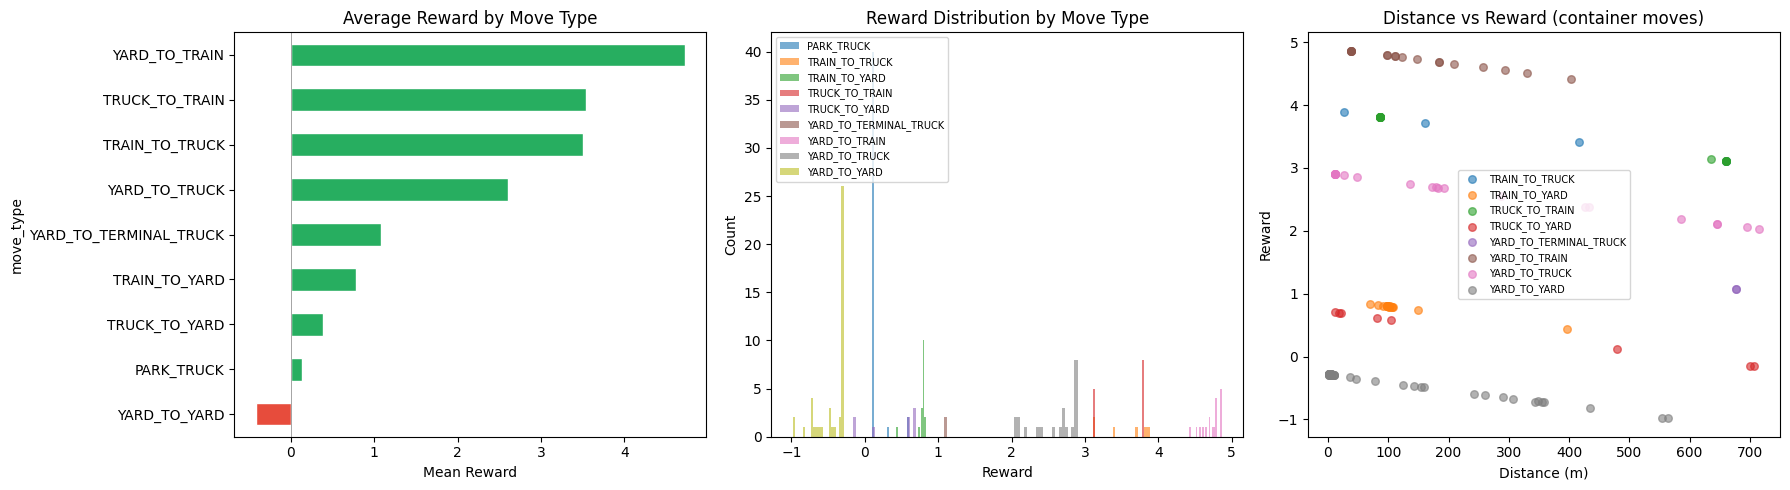

In [19]:
# ================================================================
# Reward distribution analysis
# ================================================================

if not ALL_RESULTS:
    print("No results yet -- run the tier cells above first!")
else:
    all_moves = []
    for sid, r in ALL_RESULTS.items():
        for m in r.move_log:
            all_moves.append({
                "scenario": f"S{sid}",
                "move_type": m.move_type,
                "reward": m.reward,
                "distance_m": m.distance_m,
                "time_s": m.time_s,
            })

    df_moves = pd.DataFrame(all_moves)
    print(f"Total moves across {len(ALL_RESULTS)} scenarios: {len(df_moves)}")
    print()

    if len(df_moves) > 0:
        print(df_moves.groupby("move_type").agg(
            count=("reward", "count"),
            mean_reward=("reward", "mean"),
            min_reward=("reward", "min"),
            max_reward=("reward", "max"),
            mean_dist=("distance_m", "mean"),
            mean_time=("time_s", "mean"),
        ).round(4).to_string())

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # 1) Average reward by move type
        ax = axes[0]
        grouped = df_moves.groupby("move_type")["reward"].mean().sort_values()
        colors = ["#e74c3c" if v < 0 else "#27ae60" for v in grouped.values]
        grouped.plot.barh(ax=ax, color=colors, edgecolor="white")
        ax.set_xlabel("Mean Reward")
        ax.set_title("Average Reward by Move Type")
        ax.axvline(0, color="gray", lw=0.5)

        # 2) Reward histogram
        ax = axes[1]
        for mt in sorted(df_moves["move_type"].unique()):
            subset = df_moves[df_moves["move_type"] == mt]["reward"].dropna()
            if len(subset) > 0:
                ax.hist(subset, bins=20, alpha=0.6, label=mt)
        ax.set_xlabel("Reward")
        ax.set_ylabel("Count")
        ax.set_title("Reward Distribution by Move Type")
        ax.legend(fontsize=7, loc="upper left")

        # 3) Distance vs reward
        ax = axes[2]
        container_moves = df_moves[df_moves["distance_m"] > 0].copy()
        for mt in sorted(container_moves["move_type"].unique()):
            subset = container_moves[container_moves["move_type"] == mt]
            ax.scatter(subset["distance_m"], subset["reward"], alpha=0.6, label=mt, s=30)
        ax.set_xlabel("Distance (m)")
        ax.set_ylabel("Reward")
        ax.set_title("Distance vs Reward (container moves)")
        ax.legend(fontsize=7)

        plt.tight_layout()
        plt.show()

## GPU Cleanup

In [20]:
import gc

agent.q_net.cpu()
agent.target_net.cpu()
agent.replay = None
del agent, runner
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU: {torch.cuda.memory_allocated()/1024**2:.0f} MB allocated, "
          f"{torch.cuda.memory_reserved()/1024**2:.0f} MB reserved")

GPU: 17 MB allocated, 162 MB reserved
